In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [2]:
file_path = r"C:\Users\KIIT\Downloads\LLOYD's\Customer_Churn_Data_Large.xlsx"

# Load all sheets
demographics = pd.read_excel(file_path, sheet_name='Customer_Demographics')
transactions = pd.read_excel(file_path, sheet_name='Transaction_History')
customer_service = pd.read_excel(file_path, sheet_name='Customer_Service')
online_activity = pd.read_excel(file_path, sheet_name='Online_Activity')
churn = pd.read_excel(file_path, sheet_name='Churn_Status')

In [3]:
print(demographics.head())
print(transactions.head())
print(customer_service.head())
print(online_activity.head())
print(churn.head())

   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium
   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing
   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2         

In [4]:
print(demographics.shape)
print(transactions.shape)
print(customer_service.shape)
print(online_activity.shape)
print(churn.shape)


(1000, 5)
(5054, 5)
(1002, 5)
(1000, 4)
(1000, 2)


In [5]:
print(demographics.isnull().sum())
print(transactions.isnull().sum())
print(customer_service.isnull().sum())
print(online_activity.isnull().sum())
print(churn.isnull().sum())

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64
CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64
CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64
CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64
CustomerID     0
ChurnStatus    0
dtype: int64


In [6]:
print(demographics.duplicated().sum())
print(transactions.duplicated().sum())
print(customer_service.duplicated().sum())
print(online_activity.duplicated().sum())
print(churn.duplicated().sum())


0
0
0
0
0


In [7]:
print(demographics.info())
print(transactions.info())
print(customer_service.info())
print(online_activity.info())
print(churn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       5054 non-null   int64         
 1   TransactionID    5054 non-null   int64         
 2   TransactionDate  5054 non-null   datetime64[ns]
 3   AmountSpent      5054 non-null   float64       
 4   ProductCategory  5054 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
me

In [8]:
print(demographics.describe())
print(transactions.describe())
print(online_activity.describe())

        CustomerID          Age
count  1000.000000  1000.000000
mean    500.500000    43.267000
std     288.819436    15.242311
min       1.000000    18.000000
25%     250.750000    30.000000
50%     500.500000    43.000000
75%     750.250000    56.000000
max    1000.000000    69.000000
        CustomerID  TransactionID                TransactionDate  AmountSpent
count  5054.000000    5054.000000                           5054  5054.000000
mean    501.424218    5510.538979  2022-07-01 19:25:37.158686208   250.707351
min       1.000000    1000.000000            2022-01-01 00:00:00     5.180000
25%     251.000000    3242.000000            2022-04-03 00:00:00   127.105000
50%     506.000000    5530.000000            2022-07-01 00:00:00   250.525000
75%     749.000000    7680.750000            2022-09-29 00:00:00   373.412500
max    1000.000000    9997.000000            2022-12-31 00:00:00   499.860000
std     285.172780    2582.088012                            NaN   142.250838
        Cu

In [9]:
transaction_summary = transactions.groupby('CustomerID').agg({
    'AmountSpent': ['sum', 'mean', 'count']
})

transaction_summary.columns = [
    'TotalSpent',
    'AverageSpent',
    'TransactionCount'
]

transaction_summary.reset_index(inplace=True)

In [10]:
service_summary = customer_service.groupby('CustomerID').agg({
    'InteractionID': 'count'
})

service_summary.columns = ['ServiceInteractionCount']

service_summary.reset_index(inplace=True)


In [11]:
online_summary = online_activity.groupby('CustomerID').agg({
    'LoginFrequency': 'mean'
})

online_summary.columns = ['AverageLoginFrequency']

online_summary.reset_index(inplace=True)

In [12]:
df = demographics.merge(transaction_summary, on='CustomerID', how='left')

df = df.merge(service_summary, on='CustomerID', how='left')

df = df.merge(online_summary, on='CustomerID', how='left')

df = df.merge(churn, on='CustomerID', how='left')

In [13]:
print(df.head())

print(df.shape)

   CustomerID  Age Gender MaritalStatus IncomeLevel  TotalSpent  AverageSpent  \
0           1   62      M        Single         Low      416.50     416.50000   
1           2   65      M       Married         Low     1547.42     221.06000   
2           3   18      M        Single         Low     1702.98     283.83000   
3           4   21      M       Widowed         Low      917.29     183.45800   
4           5   21      M      Divorced      Medium     2001.49     250.18625   

   TransactionCount  ServiceInteractionCount  AverageLoginFrequency  \
0                 1                      1.0                   34.0   
1                 7                      1.0                    5.0   
2                 6                      1.0                    3.0   
3                 5                      2.0                    2.0   
4                 8                      NaN                   41.0   

   ChurnStatus  
0            0  
1            1  
2            0  
3            0  
4

In [14]:
numerical_columns = [
    'TotalSpent',
    'AverageSpent',
    'TransactionCount',
    'ServiceInteractionCount',
    'AverageLoginFrequency'
]

for col in numerical_columns:
    df[col].fillna(df[col].mean(), inplace=True)


C:\Users\KIIT\AppData\Local\Temp\ipykernel_12864\728219378.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [15]:
print(df.isnull().sum())

CustomerID                 0
Age                        0
Gender                     0
MaritalStatus              0
IncomeLevel                0
TotalSpent                 0
AverageSpent               0
TransactionCount           0
ServiceInteractionCount    0
AverageLoginFrequency      0
ChurnStatus                0
dtype: int64


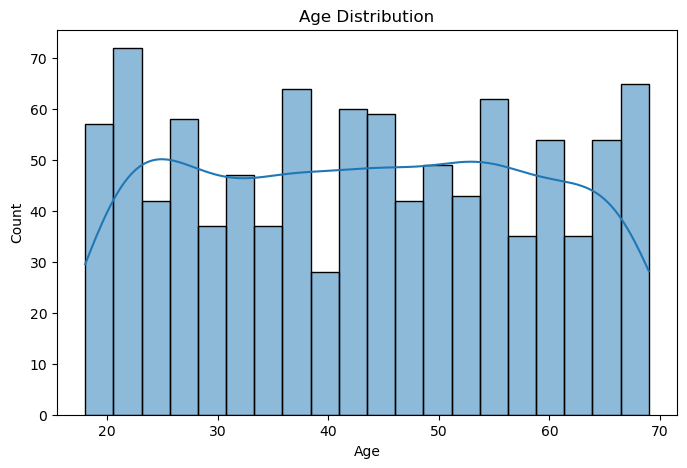

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

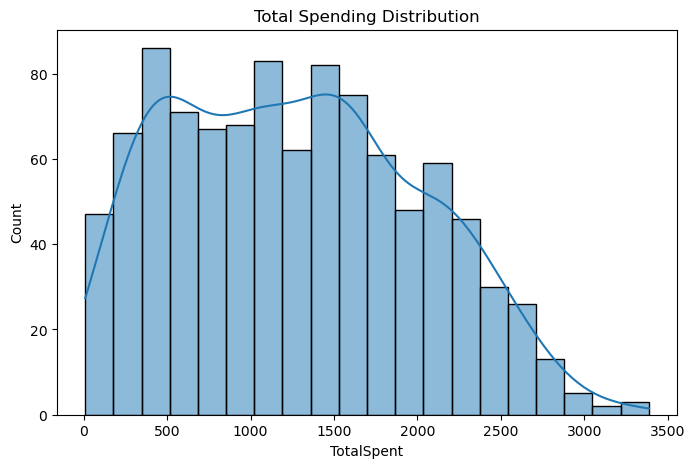

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalSpent'], bins=20, kde=True)
plt.title('Total Spending Distribution')
plt.show()

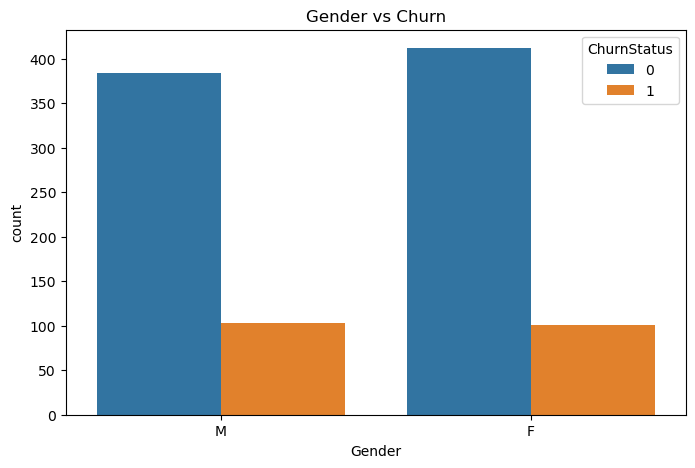

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='ChurnStatus', data=df)
plt.title('Gender vs Churn')
plt.show()

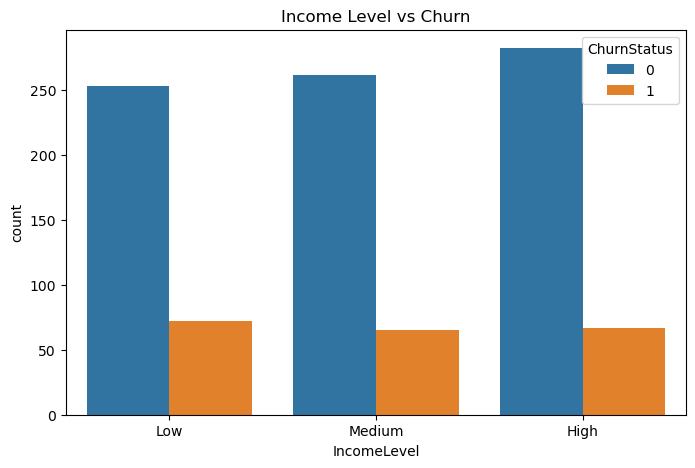

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='IncomeLevel', hue='ChurnStatus', data=df)
plt.title('Income Level vs Churn')
plt.show()


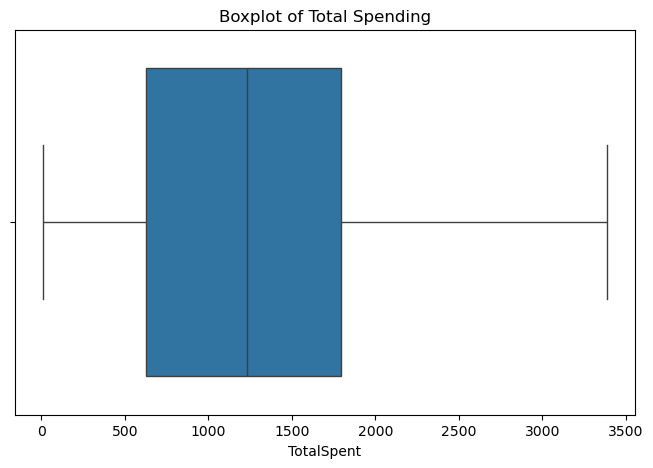

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalSpent'])
plt.title('Boxplot of Total Spending')
plt.show()

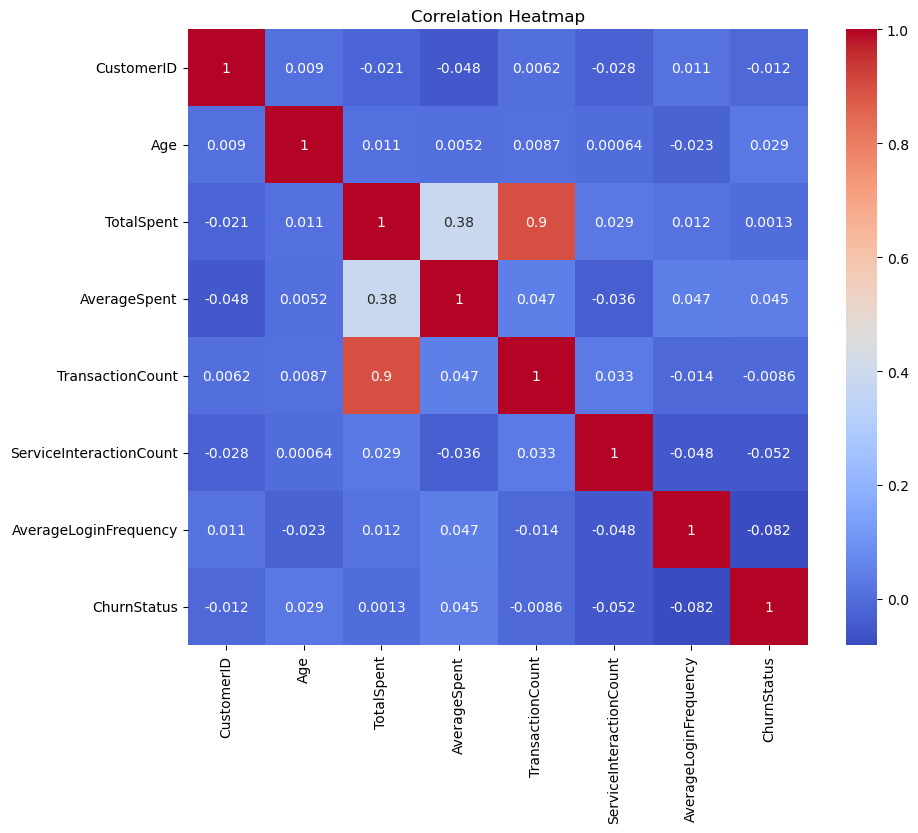

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
Q1 = df['TotalSpent'].quantile(0.25)
Q3 = df['TotalSpent'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['TotalSpent'] >= lower_limit) &
    (df['TotalSpent'] <= upper_limit)
]

In [23]:
categorical_columns = [
    'Gender',
    'MaritalStatus',
    'IncomeLevel'
]

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [24]:
scaler = StandardScaler()

scale_columns = [
    'Age',
    'TotalSpent',
    'AverageSpent',
    'TransactionCount',
    'ServiceInteractionCount',
    'AverageLoginFrequency'
]

df[scale_columns] = scaler.fit_transform(df[scale_columns])

In [25]:
print(df.head())

print(df.info())

print(df.shape)

   CustomerID       Age  TotalSpent  AverageSpent  TransactionCount  \
0           1  1.229628   -1.152196      2.113790         -1.557954   
1           2  1.426547    0.379758     -0.349747          0.747849   
2           3 -1.658518    0.590481      0.441474          0.363548   
3           4 -1.461599   -0.473822     -0.823723         -0.020752   
4           5 -1.461599    0.994845      0.017392          1.132149   

   ServiceInteractionCount  AverageLoginFrequency  ChurnStatus  Gender_M  \
0                -1.223522               0.575702            0      True   
1                -1.223522              -1.488513            1      True   
2                -1.223522              -1.630872            0      True   
3                 1.223522              -1.702052            0      True   
4                 0.000000               1.073961            0      True   

   MaritalStatus_Married  MaritalStatus_Single  MaritalStatus_Widowed  \
0                  False                  T

In [26]:
df.to_csv('Cleaned_Customer_Churn_Data.csv', index=False)

print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!
